In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from diagnostics_pkg import operators_layered as ol
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma
import qgutils as qg
import matplotlib as mpl
from numpy.fft import fft2
from numpy.fft import fftfreq
from numpy.fft import fftshift

In [2]:
def add_interval(ax, xdata, ydata, caps="  ", color = "k", theta = np.pi/2):
    # plotting function to add brackets around lines of L_jet^across and L_jet^along in the plots.
    line = ax.add_line(mpl.lines.Line2D(xdata, ydata, color = color, linewidth = 1.5))
    anno_args = {
        'ha': 'center',
        'va': 'center',
        'size': 12,
        'color': line.get_color(),
        'rotation': theta/np.pi*180 + 90
    }
    return (line)

In [3]:
def han(field):
    # applying a hanning window to field.
    han_x = np.hanning(np.shape(field)[1])
    han_y = np.hanning(np.shape(field)[0])

    field_han = field*han_x[None,:]*han_y[:,None]

    return field_han

In [4]:
def calc_JI(vorticity):

    # function that calculates the Gulf Stream Extension Index (JI here) based on the vorticity field.
    vort = han(vorticity)

    fft = abs(fft2(vort))**2/2 
    fft /= np.sum(fft) # normalize
    
    # obtain sample frequencies
    dy = (vorticity.y[1] - vorticity.y[0]) 
    dx = (vorticity.x[1] - vorticity.x[0]) 
    
    fftfreq_y = fftfreq(np.shape(vorticity)[0], dy.values)
    fftfreq_x = fftfreq(np.shape(vorticity)[1], dx.values)
    
    # calculate expected values in directional vector k_x and k_y
    N_theta = 200
    thetas = np.linspace(0,np.pi,N_theta)
    K_thetas = np.zeros(N_theta)
    
    for n, theta in enumerate(thetas):
    
        k_x = np.cos(theta)
        k_y = np.sin(theta)
        K_thetas[n] = np.sum(abs(k_y*fftfreq_y[:,None] + k_x*fftfreq_x[None,:])*fft)

    # find direction of maximum anisotropy
    L_thetas = 1/K_thetas
    idx = abs(thetas - np.pi/2).argmin()
    L_theta_orth = np.zeros(N_theta)
    idx2 = N_theta - idx
    L_theta_orth[:idx2] = L_thetas[idx:]
    L_theta_orth[idx2-1:] = L_thetas[:idx+1]

    # store results
    JI = np.max(L_thetas/L_theta_orth)
    idx = (L_thetas/L_theta_orth - JI).argmax()
    theta = thetas[idx]
    L_jet = L_thetas[idx]
    W_jet = L_theta_orth[idx]

    return JI, L_jet, W_jet, theta

In [5]:
savepath = "data/"

drho_facs = [1, 2, 4, 16]

Rs = np.zeros(len(drho_facs))

JIs = np.zeros(len(drho_facs))
Jet_Widths = np.zeros(4)

RR = 6378e3

lat_min = 25
lat_max = 50
lon_min = -80
lon_max = -40

# calculate the Extension index for all stratification configurations.

for i, drho_fac in enumerate(drho_facs):
        
    drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac
    
    # open datasets
    
    # topo mask 
    ds_topo = xr.open_dataset(savepath + "topo.nc")
    topo = ds_topo["zb"][0,0,:,:]
    mask = topo < 0
    mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
    zeros = topo*0
    
    # mean of sealevel
    ds_level = xr.open_dataset(savepath + "gulf_" + str(drho_fac) + "drho_isopycs_mean.nc", decode_times=False, chunks={"time": 10})
    ssh = ds_level["h"][-1]
    lat_mod = ssh.y
    lon_mod = ssh.x
    
    # calculate mean topography
    H = np.nanmean(topo.where(topo < 0))
    
    # calculate f0
    lat = topo.y.values
    Omega = 7.292205e-5;
    f =  (2.*Omega*np.sin(lat*np.pi/180.))
    f0 = np.mean(f)
    
    # calculate deformation radius
    
    h = np.array([250, 250, 250, 250, H - 1000])
    z = -np.cumsum(h)
    dh = (z[1:] - z[:-1])
    ddrho = drho[1:] - drho[:-1]
    ddrhodz = ddrho/dh
    N2 = - ddrhodz/1e3*9.81
    Rds, lay2mod, mod2lay = qg.comp_modes(h, N2, f0 = f0, eivec = True)
    R = Rds[1]
    Rs[i] = R
    
    # mean vorticity
    
    ds_u = xr.open_dataset(savepath + "u_mean_" + str(drho_fac) + "drho.nc")
    ds_v = xr.open_dataset(savepath + "v_mean_" + str(drho_fac) + "drho.nc")
    
    u_y = ds_u["u.x"].sel(level=4, drop=True).differentiate("y")*180/(np.pi*RR)#.where(topo < -1500, zeros)
    v_x = ds_v["u.y"].sel(level=4, drop=True).differentiate("x")/(np.pi*RR*np.cos(ds_v["u.y"].y/180*np.pi))*180#.where(topo < -1500, zeros)/(np.pi*R*np.cos(ds_v["u.y"].y/180*np.pi))*180
    
    vorticity_mean = v_x - u_y

    # scales
    
    JI, L_jet, W_jet, theta = calc_JI(vorticity_mean.where(topo < -3000, zeros).sel(x=slice(lon_min, lon_max)).sel(y=slice(lat_min, lat_max))) # only take into account areas where the topography is lower than 3000 meters
    if drho_fac == 16:
        theta = theta + np.pi
        
    JIs[i] = JI

/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip


/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/qgutils-0.5.0-py3.12.egg/qgutils/pv.py:279: RuntimeWarning: invalid value encountered in sqrt
  eigr = eigr*np.sqrt(Htt/scap)*flip


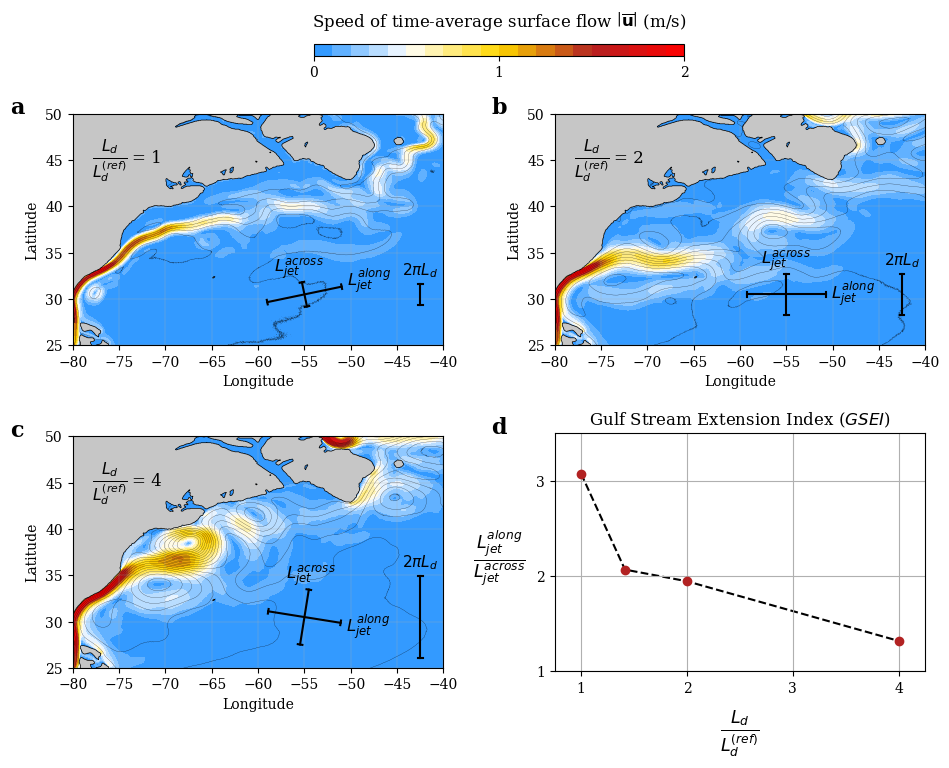

In [6]:
# mean only

savepath = "data/"

drho_facs = [1, 4, 16]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(11, 8))
grid = plt.GridSpec(2, 2, hspace=0.1, wspace=0.3)

cs = ["dodgerblue", "white", "gold", "firebrick", "red"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("cmap_name", cs)

Rd_labels = ["1", "2", "4"]
labels = ["a", "b", "c"]

iis = [0,0,1]
jjs = [0,1,0]


R0 = 39066.430787677964

for i, drho_fac in enumerate(drho_facs):
        
    drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac
    
    # open datasets
    
    # topo mask 
    ds_topo = xr.open_dataset(savepath + "topo.nc")
    topo = ds_topo["zb"][0,0,:,:]
    mask = topo < 0
    mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
    zeros = topo*0
    
    # mean of sealevel
    ds_level = xr.open_dataset(savepath + "gulf_" + str(drho_fac) + "drho_isopycs_mean.nc", decode_times=False, chunks={"time": 10})
    ssh = ds_level["h"][-1]
    lat_mod = ssh.y
    lon_mod = ssh.x

    # mean vorticity
    
    ds_u = xr.open_dataset(savepath + "u_mean_" + str(drho_fac) + "drho.nc")
    ds_v = xr.open_dataset(savepath + "v_mean_" + str(drho_fac) + "drho.nc")
    
    u_y = ds_u["u.x"].sel(level=4, drop=True).differentiate("y")*180/(np.pi*RR)#.where(topo < -1500, zeros)
    v_x = ds_v["u.y"].sel(level=4, drop=True).differentiate("x")/(np.pi*RR*np.cos(ds_v["u.y"].y/180*np.pi))*180#.where(topo < -1500, zeros)/(np.pi*R*np.cos(ds_v["u.y"].y/180*np.pi))*180
    
    vorticity_mean = v_x - u_y
    speed_mean = np.sqrt(ds_u["u.x"].sel(level=4, drop=True)**2 + ds_v["u.y"].sel(level=4, drop=True)**2)
    
    # scales
    
    JI, L_jet, W_jet, theta = calc_JI(vorticity_mean.where(topo < -3000, zeros).sel(x=slice(lon_min, lon_max)).sel(y=slice(lat_min, lat_max)))
    if drho_fac == 16:
        theta = theta + np.pi
        
    # calculate mean topography
    H = np.nanmean(topo.where(topo < 0))
    
    # calculate f0
    lat = topo.y.values
    Omega = 7.292205e-5;
    f =  (2.*Omega*np.sin(lat*np.pi/180.))
    f0 = np.mean(f)
    
    # calculate deformation radius
    
    h = np.array([250, 250, 250, 250, H - 1000])
    z = -np.cumsum(h)
    dh = (z[1:] - z[:-1])
    ddrho = drho[1:] - drho[:-1]
    ddrhodz = ddrho/dh
    N2 = - ddrhodz/1e3*9.81
    Rds, lay2mod, mod2lay = qg.comp_modes(h, N2, f0 = f0, eivec = True)
    R = Rds[1]
    R_0 = 39066.430787677964
    
    axes = fig.add_subplot(grid[iis[i],jjs[i]])

    #  mean sea level
    
    v = 2
    levels = np.linspace(-v, v, 21)
    
    axes.contour(lon_mod, lat_mod, ssh, vmin = -v, vmax = v, colors = 'k', levels = levels, linewidths = 0.15, linestyles = "-")

    # coastlines
    axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
    axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)

    v = 2
    levels = np.linspace(0, v, 21)
    
    # mean speed fields
    axes.pcolormesh(lon_mod, lat_mod, speed_mean, vmin = 0, vmax = v, cmap = cmap)
    cplot = axes.contourf(lon_mod, lat_mod, speed_mean, vmin = 0, vmax = v, cmap = cmap, levels = levels)
    
    axes.set_xlabel("Longitude")
    axes.set_ylabel("Latitude")

    axes.text(-0.15, 1.025, labels[i], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

    if i == 0:
        #axes.set_title("time-average surface flow")
        # add text for axis label
        divider = make_axes_locatable(axes)
        cax = axes.inset_axes((0.65, 1.25,1, 0.05))
        
        cbar = plt.colorbar(cplot, cax=cax, orientation='horizontal', ticks = [0, v/2, v])
        cax.set_xlabel('Speed of time-average surface flow ' + r'$\left|\overline{\mathbf{u}}\right|$ (m/s)', size = 12, rotation = 0)
        cax.xaxis.set_label_coords(0.5,4)
        #cax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        
    # add jet scales

    lon_scales = -55
    lat_scales = 30.5

    text_dist_along = 3
    text_dist_across = 1.5
    L_along_x = L_jet*np.cos(theta)
    L_along_y = L_jet*np.sin(theta)
    L_across_x = W_jet*np.cos(theta + np.pi/2)
    L_across_y = W_jet*np.sin(theta + np.pi/2)
    
    add_interval(axes, (lon_scales - L_along_x/2, lon_scales + L_along_x/2), (lat_scales - L_along_y/2, lat_scales + L_along_y/2), "--", "k", theta = theta)
    axes.text(lon_scales + L_along_x/2 + L_along_x/np.sqrt(L_along_x**2 + L_along_y**2)*text_dist_along, lat_scales + L_along_y/2 + L_along_y/np.sqrt(L_along_x**2 + L_along_y**2)*text_dist_along, r"$L^{along}_{jet}$", horizontalalignment='center', verticalalignment='center', size = 12)

    add_interval(axes, (lon_scales - L_across_x/2, lon_scales + L_across_x/2), (lat_scales - L_across_y/2, lat_scales + L_across_y/2), "--", "k", theta = theta+np.pi/2)
    axes.text(lon_scales + L_across_x/2 + L_across_x/np.sqrt(L_across_x**2 + L_across_y**2)*text_dist_across, lat_scales + L_across_y/2 + L_across_y/np.sqrt(L_across_x**2 + L_across_y**2)*text_dist_across, r"$L^{across}_{jet}$", horizontalalignment='center', verticalalignment='center', size = 12)

    # add caps
    cap_len = 0.5
    cap_x = -cap_len*np.sin(theta)
    cap_y = cap_len*np.cos(theta)
    
    add_interval(axes, (lon_scales + L_along_x/2 - cap_x/2, lon_scales + L_along_x/2 + cap_x/2), (lat_scales + L_along_y/2 - cap_y/2, lat_scales + L_along_y/2 + cap_y/2), "--", "k")
    add_interval(axes, (lon_scales - L_along_x/2 - cap_x/2, lon_scales - L_along_x/2 + cap_x/2), (lat_scales - L_along_y/2 - cap_y/2, lat_scales - L_along_y/2 + cap_y/2), "--", "k")

    cap_x = cap_len*np.cos(theta)
    cap_y = cap_len*np.sin(theta)
    
    add_interval(axes, (lon_scales + L_across_x/2 - cap_x/2, lon_scales + L_across_x/2 + cap_x/2), (lat_scales + L_across_y/2 - cap_y/2, lat_scales + L_across_y/2 + cap_y/2), "--", "k")
    add_interval(axes, (lon_scales - L_across_x/2 - cap_x/2, lon_scales - L_across_x/2 + cap_x/2), (lat_scales - L_across_y/2 - cap_y/2, lat_scales - L_across_y/2 + cap_y/2), "--", "k")
    
    # add Deformation Radius
    R_deg = 2*np.pi*R/(2*np.pi*RR)*360
    Ld_lon = -42.5
    Ld_lat = 30.5
    add_interval(axes, (Ld_lon, Ld_lon), (Ld_lat + R_deg/2, Ld_lat - R_deg/2), "--", "k")
    
    add_interval(axes, (Ld_lon - cap_len/2, Ld_lon + cap_len/2), (Ld_lat + R_deg/2, Ld_lat + R_deg/2), "--", "k")
    add_interval(axes, (Ld_lon - cap_len/2, Ld_lon + cap_len/2), (Ld_lat - R_deg/2, Ld_lat - R_deg/2), "--", "k")
    
    axes.text(Ld_lon, Ld_lat + R_deg/2 + 1.5, r"$2\pi L_d$", horizontalalignment='center', verticalalignment='center', size = 11)

    # add text for deformation radius
    axes.text(0.1, 0.8, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    axes.text(0.16, 0.8075, '= ' + Rd_labels[i], verticalalignment='center', transform=axes.transAxes, size = 12)
    
    # add grid
    axes.grid(zorder = 1, linewidth = 0.2)
    
    # set lateral and longitudinal extend
    axes.set_xlim([lon_min, lon_max])
    axes.set_ylim([lat_min, lat_max])
    axes.set_aspect(1)

axes = fig.add_subplot(grid[1,1])
# axes.set_axis_off()
# divider = make_axes_locatable(axes)
# axes = axes.inset_axes((0, -0.4,1, 1))
axes.grid(which = 'both', zorder = 0)
axes.plot(Rs/R0, JIs, linestyle = "--", color = "k", zorder = 1)
axes.scatter(Rs/R0, JIs, linestyle = "None", zorder = 12, fc = "firebrick")
#axes.set_xscale("log")
axes.set_xlim([0.75, 4.25])
axes.set_ylim([1, 3.5])
axes.set_aspect(0.9)
axes.set_xticks([1,2,3,4], ("1","2","3","4"))
axes.set_yticks([1,2,3], ("1","2","3"))
axes.set_xlabel(r'$\frac{L_d}{L_d^{(ref)}}$', size = 18)
axes.xaxis.set_label_coords(0.5,-0.15)
axes.set_ylabel(r'$\frac{L_{jet}^{along}}{L_{jet}^{across}}$', size = 18, rotation = 0)
axes.yaxis.set_label_coords(-0.15,0.35)
axes.text(-0.15, 1.025, "d", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
axes.set_title("Gulf Stream Extension Index ($GSEI$)")

plt.savefig('JI_speed_only.png', dpi = 400, bbox_inches='tight', format = 'png')